# Momentum Methods: Heavy-Ball and Nesterov Acceleration

Plain gradient descent on $\mu$-strongly convex, $L$-smooth $f$ converges as $O((1-\mu/L)^k)$. **Momentum methods** break this barrier by using past iterates.

## Heavy-ball (Polyak 1964)

The **heavy-ball** method adds an inertia term:
$$
x^{k+1} = x^k - \tau \nabla f(x^k) + \beta (x^k - x^{k-1}),
$$
where $\beta \in [0,1)$ is the **momentum coefficient**. For a quadratic $f$ with eigenvalues in $[\mu, L]$, the optimal parameters are:
$$
\tau^* = \frac{4}{(\sqrt{L}+\sqrt{\mu})^2}, \qquad \beta^* = \left(\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1}\right)^2,
$$
giving the **optimal linear rate** $O\!\left((\frac{\sqrt{\kappa}-1}{\sqrt{\kappa}+1})^k\right)$ vs. $O\!\left((\frac{\kappa-1}{\kappa+1})^k\right)$ for GD.

## Nesterov acceleration (1983)

Nesterov's method achieves the same optimal rate but with a **lookahead gradient**:
$$
y^{k+1} = x^k + \beta_k (x^k - x^{k-1}),\quad x^{k+1} = y^{k+1} - \tau \nabla f(y^{k+1}),
$$
with momentum $\beta_k = (t_k - 1)/t_{k+1}$ and $t_{k+1} = \frac{1+\sqrt{1+4t_k^2}}{2}$. For general convex $f$ Nesterov achieves $O(1/k^2)$ vs. $O(1/k)$ for GD.

## The acceleration gap

For condition number $\kappa = L/\mu$:
- GD rate: $\rho_{\text{GD}} = (\kappa-1)/(\kappa+1) \approx 1 - 2/\kappa$ for large $\kappa$.
- Optimal rate: $\rho^* = (\sqrt{\kappa}-1)/(\sqrt{\kappa}+1) \approx 1 - 2/\sqrt{\kappa}$.

Acceleration replaces $\kappa$ by $\sqrt{\kappa}$ in the exponent — a dramatic speedup for ill-conditioned problems.

## Environment

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider

plt.rcParams['figure.dpi'] = 120

## Anisotropic quadratic objective

We minimise $f(x) = \frac{1}{2}x^\top A x$ where $A = \mathrm{diag}(\mu, L)$, so $\kappa = L/\mu$. The minimum is at the origin.

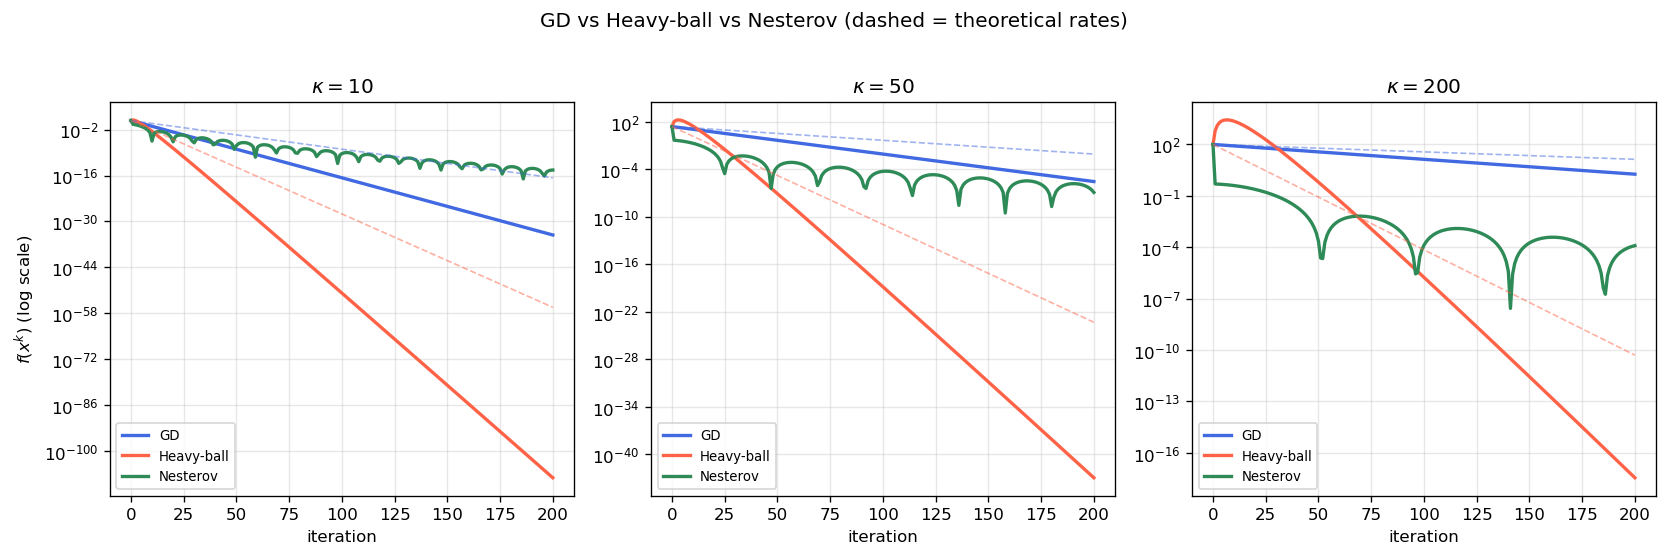

In [2]:
def run_gd(mu, L, n_iter, x0=None):
    if x0 is None: x0 = np.array([1.0, 1.0])
    tau = 2.0 / (mu + L)
    x = x0.copy(); fvals = [0.5*(mu*x[0]**2 + L*x[1]**2)]
    for _ in range(n_iter):
        g = np.array([mu*x[0], L*x[1]])
        x = x - tau * g
        fvals.append(0.5*(mu*x[0]**2 + L*x[1]**2))
    return np.array(fvals)

def run_heavy_ball(mu, L, n_iter, x0=None):
    if x0 is None: x0 = np.array([1.0, 1.0])
    sq = np.sqrt(L/mu)
    tau = 4.0 / (np.sqrt(L) + np.sqrt(mu))**2
    beta = ((sq - 1) / (sq + 1))**2
    x_prev = x0.copy(); x = x0.copy()
    fvals = [0.5*(mu*x[0]**2 + L*x[1]**2)]
    for _ in range(n_iter):
        g = np.array([mu*x[0], L*x[1]])
        x_new = x - tau * g + beta * (x - x_prev)
        x_prev, x = x, x_new
        fvals.append(0.5*(mu*x[0]**2 + L*x[1]**2))
    return np.array(fvals)

def run_nesterov(mu, L, n_iter, x0=None):
    if x0 is None: x0 = np.array([1.0, 1.0])
    tau = 1.0 / L
    x_prev = x0.copy(); x = x0.copy(); t = 1.0
    fvals = [0.5*(mu*x[0]**2 + L*x[1]**2)]
    for _ in range(n_iter):
        t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
        beta = (t - 1) / t_new
        y = x + beta * (x - x_prev)
        g = np.array([mu*y[0], L*y[1]])
        x_prev, x, t = x, y - tau * g, t_new
        fvals.append(0.5*(mu*x[0]**2 + L*x[1]**2))
    return np.array(fvals)

# Compare for several condition numbers
kappas = [10, 50, 200]
fig, axes = plt.subplots(1, len(kappas), figsize=(14, 4.5))

for ax, kappa in zip(axes, kappas):
    mu, L = 1.0, float(kappa)
    k = np.arange(201)
    f_gd  = run_gd(mu, L, 200)
    f_hb  = run_heavy_ball(mu, L, 200)
    f_nes = run_nesterov(mu, L, 200)
    ax.semilogy(f_gd, 'royalblue', lw=2, label='GD')
    ax.semilogy(f_hb, 'tomato', lw=2, label='Heavy-ball')
    ax.semilogy(f_nes, 'seagreen', lw=2, label='Nesterov')
    # Theoretical rates
    rho_gd = (kappa - 1) / (kappa + 1)
    rho_opt = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)
    ax.semilogy(k, f_gd[0] * rho_gd**k, 'royalblue', ls='--', lw=1, alpha=0.5)
    ax.semilogy(k, f_gd[0] * rho_opt**k, 'tomato', ls='--', lw=1, alpha=0.5)
    ax.set_title(f'$\\kappa={kappa}$'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    ax.set_xlabel('iteration')

axes[0].set_ylabel('$f(x^k)$ (log scale)')
fig.suptitle('GD vs Heavy-ball vs Nesterov (dashed = theoretical rates)', y=1.02)
plt.tight_layout(); plt.show()

## Trajectories in 2D

For the 2D quadratic we can visualise the spiraling trajectory of the heavy-ball method and the smoother Nesterov path.

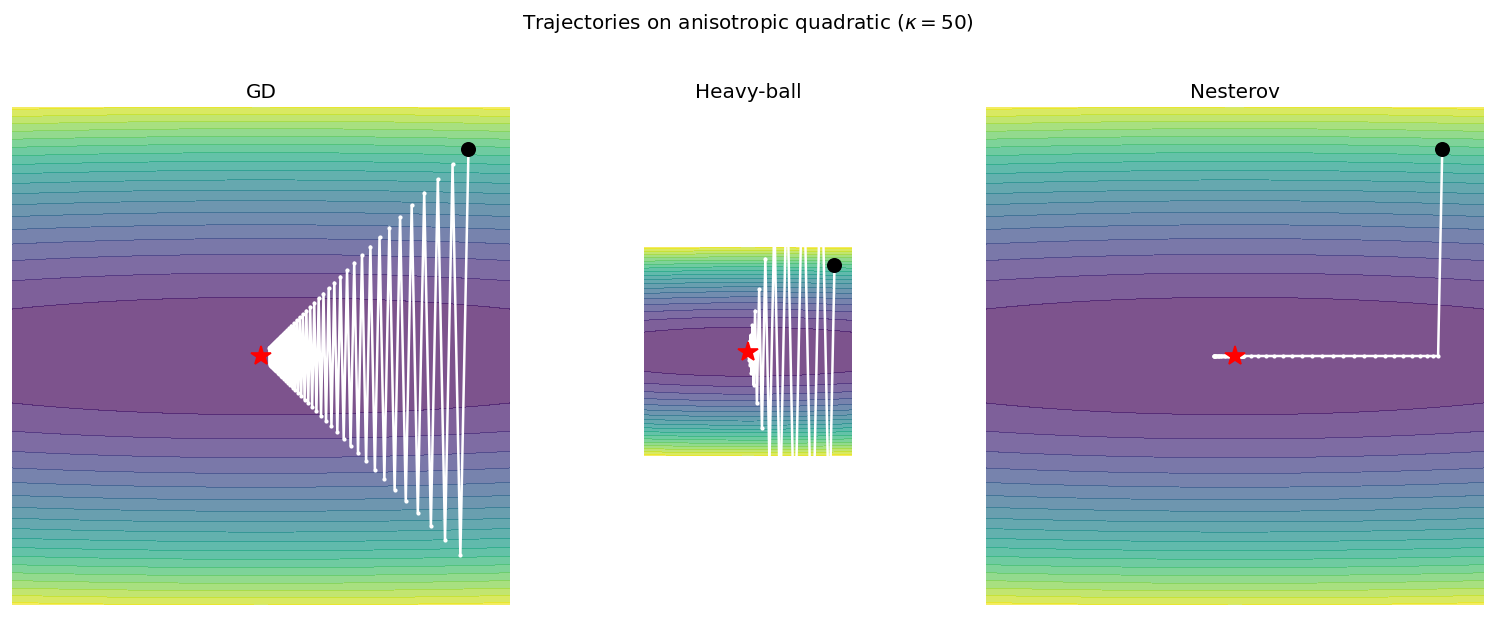

In [3]:
def run_gd_traj(mu, L, n_iter):
    tau = 2.0 / (mu + L)
    x = np.array([1.0, 1.0]); traj = [x.copy()]
    for _ in range(n_iter):
        x = x - tau * np.array([mu*x[0], L*x[1]])
        traj.append(x.copy())
    return np.array(traj)

def run_hb_traj(mu, L, n_iter):
    tau = 4.0 / (np.sqrt(L) + np.sqrt(mu))**2
    beta = ((np.sqrt(L/mu) - 1)/(np.sqrt(L/mu) + 1))**2
    x_prev = np.array([1.0, 1.0]); x = x_prev.copy(); traj = [x.copy()]
    for _ in range(n_iter):
        g = np.array([mu*x[0], L*x[1]])
        x_new = x - tau * g + beta * (x - x_prev)
        x_prev, x = x, x_new; traj.append(x.copy())
    return np.array(traj)

def run_nes_traj(mu, L, n_iter):
    tau = 1.0/L; t = 1.0
    x_prev = np.array([1.0, 1.0]); x = x_prev.copy(); traj = [x.copy()]
    for _ in range(n_iter):
        t_new = (1 + np.sqrt(1 + 4*t**2)) / 2
        beta = (t - 1) / t_new
        y = x + beta * (x - x_prev)
        g = np.array([mu*y[0], L*y[1]])
        x_prev, x, t = x, y - tau * g, t_new; traj.append(x.copy())
    return np.array(traj)

kappa = 50; mu, L = 1.0, float(kappa)
N = 80

fig, axes = plt.subplots(1, 3, figsize=(13, 5))
for ax, (name, traj) in zip(axes, [
    ('GD', run_gd_traj(mu, L, N)),
    ('Heavy-ball', run_hb_traj(mu, L, N)),
    ('Nesterov', run_nes_traj(mu, L, N)),
]):
    xi = np.linspace(-1.2, 1.2, 200); yi = np.linspace(-1.2, 1.2, 200)
    X, Y = np.meshgrid(xi, yi)
    F = 0.5*(mu*X**2 + L*Y**2)
    ax.contourf(xi, yi, F, levels=20, cmap='viridis', alpha=0.7)
    ax.plot(traj[:,0], traj[:,1], '.-', lw=1.5, ms=3, color='white')
    ax.plot(traj[0,0], traj[0,1], 'ko', ms=8)
    ax.plot(0, 0, 'r*', ms=12)
    ax.set_aspect('equal'); ax.set_title(name); ax.axis('off')

fig.suptitle(f'Trajectories on anisotropic quadratic ($\\kappa={kappa}$)', y=1.02)
plt.tight_layout(); plt.show()

## Interactive: condition number and iterations

In [4]:
def show_momentum(kappa=50, n_iter=200):
    mu, L = 1.0, float(kappa)
    f_gd  = run_gd(mu, L, n_iter)
    f_hb  = run_heavy_ball(mu, L, n_iter)
    f_nes = run_nesterov(mu, L, n_iter)
    k = np.arange(n_iter + 1)
    rho_gd = (kappa - 1) / (kappa + 1)
    rho_opt = (np.sqrt(kappa) - 1) / (np.sqrt(kappa) + 1)
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.semilogy(f_gd,  'royalblue', lw=2, label='GD')
    ax.semilogy(f_hb,  'tomato',    lw=2, label='Heavy-ball')
    ax.semilogy(f_nes, 'seagreen',  lw=2, label='Nesterov')
    ax.semilogy(k, f_gd[0]*rho_gd**k, 'royalblue', ls=':', lw=1.2, alpha=0.6, label=f'GD rate $\\rho={rho_gd:.3f}$')
    ax.semilogy(k, f_gd[0]*rho_opt**k,'tomato',     ls=':', lw=1.2, alpha=0.6, label=f'Opt rate $\\rho={rho_opt:.3f}$')
    ax.set_xlabel('iteration'); ax.set_ylabel('$f(x^k)$')
    ax.set_title(f'$\\kappa={kappa}$'); ax.legend(fontsize=8); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

interact(show_momentum,
         kappa=IntSlider(value=50, min=2, max=500, step=10, description='$\\kappa$'),
         n_iter=IntSlider(value=200, min=50, max=600, step=50, description='iters'));

interactive(children=(IntSlider(value=50, description='$\\kappa$', max=500, min=2, step=10), IntSlider(value=2…

## Bibliographical resources

- Polyak, B. T. (1964). Some methods of speeding up the convergence of iteration methods. *USSR Computational Mathematics and Mathematical Physics*, 4(5), 1–17.
- Nesterov, Y. (1983). A method for solving the convex programming problem with convergence rate $O(1/k^2)$. *Soviet Mathematics Doklady*, 27, 372–376.
- Nesterov, Y. (2004). *Introductory Lectures on Stochastic Optimization*. Kluwer.
- Su, W., Boyd, S. and Candès, E. J. (2016). A differential equation for modeling Nesterov's accelerated gradient method. *Journal of Machine Learning Research*, 17(153), 1–43.
- Lessard, L., Recht, B. and Packard, A. (2016). Analysis and design of optimization algorithms via integral quadratic constraints. *SIAM Journal on Optimization*, 26(1), 57–95.